# Correlated-Attention QCNN Pipeline (CIFAR-10) — v6

**v6 combines three published quantum-ML ideas with the v5 flat weight-shared
parallel QCNN, plus rebalances the parameter budget from classical to
quantum:**

| Idea | Source | How it's used here |
|---|---|---|
| Parallel, weight-shared quantum circuits applied to CNN feature partitions (HQNN-Parallel) | Senokosov et al., *Mach. Learn.: Sci. Technol.* 5 015040 (2024) | The core structure carried over from v4/v5: one shared circuit broadcast over 64 spatial partitions of the CNN feature map. v6 makes this circuit substantially deeper. |
| Correlation-regularized CNN features feeding the quantum block | Seong & Kim, *"Image Classification Using CNN-QNN Hybrid Model with Optimized Correlated Features"*, arXiv:2608.04379 | An extra training-loss term drives the CNN's per-partition features toward the paper's empirically-optimal ~0.5 average pairwise correlation, so they better match the entangling structure of the downstream circuit. |
| Quantum attention mechanism (QAttn) | Pandey & Mandal, *Sci. Rep.* 16:1639 (2025), QAttn-CNN | Rather than adding a second quantum circuit, v6 reads an **extra observable off the qubits the pooling step would otherwise discard** and uses it as a per-partition attention logit — a softmax-normalized reweighting of the 64 partitions' quantum features, at zero extra circuit calls. |

**Parameter rebalancing** (the actual ask: fewer classical, more quantum params):
- Classical CNN front end shrunk `3->8->16` channels &rarr; `3->4->16` (roughly
  halves the classical conv parameters).
- Quantum block deepened: the re-upload entangling ring is now applied twice
  per chunk (was once), the main QCNN convolution goes from depth 2 to depth
  4, and a second (unpooled) QCNN convolution block is added on the 4 kept
  qubits purely to add expressive quantum capacity before measurement.
  Quantum trainable parameters roughly double as a result.

This is **not** a reproduction of any single paper's numbers (those were
obtained under very different training budgets/hardware/dataset splits) —
it is a from-scratch architecture built by combining the *mechanisms* those
three papers introduce with the existing v5 pipeline.


## 1. Setup


In [1]:
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)

DEVICE = "cpu"   # the quantum QNode below is CPU-only (default.qubit); the
                  # classical CNN/Linear layers would happily move to GPU, but
                  # keeping everything on one device avoids host<->device
                  # transfer overhead on every batch given how small the
                  # tensors are.
print("torch:", torch.__version__, "| pennylane:", qml.__version__, "| device:", DEVICE)


torch: 2.5.1+cu121 | pennylane: 0.44.1 | device: cpu


## 2. CNN feature extractor (slimmed down, v6)

Same two-conv-layer front end as v5, but the first conv's output width is
halved (`8ch -> 4ch`), which roughly halves the classical parameter count of
the whole front end. `32x32x3 -> 16x16x4 -> 8x8x16`, reshaped to 64
partitions of 16 dims each (unchanged downstream shape, so nothing else has
to change to accommodate the smaller first layer).


In [2]:
class CNNFeatureExtractor(nn.Module):
    '''2-conv-layer front end (v6: slimmed first layer):
    32x32x3 -> conv(4ch) -> ReLU -> maxpool(2x2) -> 16x16x4
             -> conv(16ch) -> ReLU -> maxpool(2x2) -> 8x8x16
             -> reshape -> 64 partitions x 16 dims
    '''
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  4, kernel_size=3, stride=1, padding=1, bias=False)
        self.conv2 = nn.Conv2d(4, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.pool  = nn.MaxPool2d(2, 2)

    def forward(self, x):                        # (B, 3, 32, 32)
        x = self.pool(F.relu(self.conv1(x)))      # (B, 4, 16, 16)
        x = self.pool(F.relu(self.conv2(x)))      # (B, 16, 8, 8)
        x = x.permute(0, 2, 3, 1)                 # (B, 8, 8, 16)
        x = x.reshape(x.shape[0], 64, 16)         # (B, 64, 16) -- 64 partitions of 16 dims
        return x

cnn = CNNFeatureExtractor()
print(f"classical CNN params: {sum(p.numel() for p in cnn.parameters()):,}  "
      f"(v5 front end was 1,368 -- this is the classical-parameter reduction)")

with torch.no_grad():
    dummy = torch.randn(2, 3, 32, 32)
    feat = cnn(dummy)
    print("partition tensor shape:", feat.shape, " (batch, 64 partitions, 16 dims each)")


classical CNN params: 684  (v5 front end was 1,368 -- this is the classical-parameter reduction)
partition tensor shape: torch.Size([2, 64, 16])  (batch, 64 partitions, 16 dims each)


## 3. Quantum building blocks (deepened re-upload + QCNN, plus a correlation-regularization helper)

`reupload_two_chunks` now applies the trainable CRY entangling ring **twice**
per chunk instead of once (`ENT_ROUNDS = 2`), and `qcnn_layer` is unchanged
in structure from v5 but is reused twice per forward pass at greater total
depth (see Sec. 4): once at `CONV_DEPTH = 4` for the main 8-qubit
convolution+pool, and again at `ATTN_DEPTH = 2` on the 4 surviving qubits to
add further quantum capacity before measurement.

`feature_correlation_reg` is the Seong & Kim-style regularizer: it takes the
CNN's per-partition feature vectors (before they enter the quantum circuit),
computes their empirical correlation matrix across the batch, and returns
how far the mean off-diagonal correlation is from the paper's
empirically-optimal target of 0.5.


In [3]:
N_REG      = 8      # register each partition's two chunks reupload onto
SINK       = 4       # qubits kept after the main conv+pool step (8 -> 4)
CONV_DEPTH = 4        # main QCNN convolution depth (v5 was 2 -- doubled)
ATTN_DEPTH = 2        # extra unpooled QCNN depth applied to the 4 kept qubits
ENT_ROUNDS = 2        # trainable CRY entangling rounds per re-upload chunk (v5 was 1)
TARGET_CORR = 0.5     # Seong & Kim's empirically-optimal mean feature correlation

def reupload_two_chunks(chunk1, chunk2, wires, ent_weights, ent_rounds=ENT_ROUNDS):
    '''Reupload chunk1, entangle (CNOT ring + `ent_rounds` trainable CRY rings),
    then reupload chunk2 onto the SAME register and entangle again the same
    way. `ent_weights` has shape (2, ent_rounds, len(wires)) -- one CRY-ring
    row per (chunk, round).'''
    n = len(wires)
    for r, chunk in enumerate((chunk1, chunk2)):
        for i, w in enumerate(wires):
            qml.Hadamard(wires=w)
            qml.RY((math.pi / 4) * chunk[..., i], wires=w)
        for i in range(n):                                    # CNOT ring
            qml.CNOT(wires=[wires[i], wires[(i + 1) % n]])
        for rnd in range(ent_rounds):                          # deepened: >=2 trainable CRY rings
            for i in range(n):
                qml.CRY(ent_weights[r, rnd, i], wires=[wires[i], wires[(i + 1) % n]])


def qcnn_layer(wires, conv_w, pool_w, depth, pool=True):
    '''One QCNN block: `depth` rounds of parameterised 2-qubit convolution,
    then (if `pool`) a controlled-rotation pooling step that keeps one qubit
    per pair and drops the other. If `pool=False`, no measurement-relevant
    qubits are dropped -- this is used for the extra ATTN_DEPTH pass, which
    only adds expressivity and does not shrink the register.'''
    n = len(wires)
    npairs = n // 2
    for layer in range(depth):
        w_offset = layer * npairs
        for idx in range(npairs):
            a, b = wires[2 * idx], wires[2 * idx + 1]
            qml.RY(conv_w[w_offset + idx, 0], wires=a)
            qml.RY(conv_w[w_offset + idx, 1], wires=b)
            qml.CNOT(wires=[a, b])
            qml.RZ(conv_w[w_offset + idx, 2], wires=b)
            qml.CNOT(wires=[a, b])
    if not pool:
        return list(wires), []
    kept, dropped = [], []
    for idx in range(npairs):
        a, b = wires[2 * idx], wires[2 * idx + 1]
        qml.CRY(pool_w[idx], wires=[b, a])     # controlled-pool: b folds into a
        kept.append(a)
        dropped.append(b)
    if n % 2 == 1:
        kept.append(wires[-1])                  # carry an odd leftover through untouched
    return kept, dropped


def feature_correlation_reg(v, target_corr=TARGET_CORR):
    '''Seong & Kim-style correlation regularizer. `v` is the CNN's (B, 64, 16)
    partition-feature tensor -- i.e. exactly what is about to be re-uploaded
    onto the quantum register. Treats every (image, partition) pair as one
    sample of a 16-dim feature vector, computes the empirical 16x16
    correlation matrix across all those samples, and returns
    (mean_abs_offdiag_corr, squared_distance_to_target) -- the second value is
    the term added to the training loss.'''
    flat = v.reshape(-1, v.shape[-1])                       # (B*64, 16)
    flat = flat - flat.mean(dim=0, keepdim=True)
    std  = flat.std(dim=0, keepdim=True) + 1e-6
    flat_n = flat / std
    corr = (flat_n.T @ flat_n) / flat.shape[0]               # (16, 16)
    D = corr.shape[0]
    off_diag_mask = ~torch.eye(D, dtype=torch.bool, device=corr.device)
    mean_offdiag = corr[off_diag_mask].abs().mean()
    return mean_offdiag, (mean_offdiag - target_corr) ** 2


## 4. The single QNode: deepened re-upload -> deep QCNN -> pool -> extra QCNN -> measure (+ free attention readout)

Structurally still **one** `default.qubit` QNode, `backprop`-differentiated,
broadcasting over the leading `batch_size * 64` dimension exactly as in v5 --
so there is still no Python-level loop over the 64 partitions and no
per-call QNode overhead.

Two changes from v5:
1. After the main conv+pool step (`8 -> 4` qubits), a **second, unpooled**
   `qcnn_layer` call at `ATTN_DEPTH` adds more trainable entanglement to the
   4 surviving qubits before they're measured.
2. The pooling step's **dropped** qubits are not discarded from the
   simulation (pooling here is a controlled rotation, not a real qubit
   loss) -- v6 measures a joint parity observable on them and returns it as
   a **quantum attention logit**, reusing information v5 threw away for
   free (no extra circuit evaluation).


In [4]:
dev_local = qml.device("default.qubit", wires=N_REG)

@qml.qnode(dev_local, interface="torch", diff_method="backprop")
def local_block_measure(chunk1, chunk2, ent, conv_l, pool_l, conv_l2):
    '''Broadcasts over batch_size * 64 partitions at once. Returns:
      - 4 <Z> expectation values on the kept (post-pool) qubits, after the
        extra ATTN_DEPTH convolution -- the classification features.
      - 1 joint-parity expectation value on the 4 dropped (pooled-away)
        qubits -- the quantum attention logit, read for free off qubits that
        are otherwise unused after pooling.
    Returns a flat list of 5 tensors, each of shape (batch*64,).'''
    wires = list(range(N_REG))
    reupload_two_chunks(chunk1, chunk2, wires, ent)
    kept, dropped = qcnn_layer(wires, conv_l, pool_l, depth=CONV_DEPTH, pool=True)    # 8 -> 4
    qcnn_layer(kept, conv_l2, None, depth=ATTN_DEPTH, pool=False)                      # extra depth, no further pooling
    feature_exp = [qml.expval(qml.PauliZ(w)) for w in kept]
    attn_obs = qml.PauliZ(dropped[0]) @ qml.PauliZ(dropped[1]) @ qml.PauliZ(dropped[2]) @ qml.PauliZ(dropped[3])
    attn_logit = qml.expval(attn_obs)
    return feature_exp + [attn_logit]


## 5. `QuantumParallelBlock`: same circuit on all 64 partitions, now with quantum attention

Holds **one** set of trainable weights (`ent`, `conv_l`, `pool_l`, `conv_l2`)
shared across all 64 partitions -- the same weight-sharing as v5/Senokosov
et al.'s HQNN-Parallel, just with a bigger weight set per the deepened
circuit above. After the single broadcasted QNode call, the 4 feature
values per partition are reweighted by a **softmax over the attention
logits across the 64 partitions** (per image) before being flattened for
the classifier head -- partitions the quantum attention circuit judges more
informative contribute more to the final 256-dim feature vector.


In [5]:
class QuantumParallelBlock(nn.Module):
    def __init__(self, n_partitions=64):
        super().__init__()
        self.n_partitions = n_partitions
        self.ent    = nn.Parameter(0.1 * torch.randn(2, ENT_ROUNDS, N_REG))        # 2*2*8  = 32 params
        self.conv_l = nn.Parameter(0.1 * torch.randn(CONV_DEPTH * 4, 3))            # 4*4*3  = 48 params
        self.pool_l = nn.Parameter(0.1 * torch.randn(4))                            #          4 params
        self.conv_l2 = nn.Parameter(0.1 * torch.randn(ATTN_DEPTH * 2, 3))           # 2*2*3  = 12 params

    def forward(self, vectors):                       # (B, 64, 16)
        B, V, _ = vectors.shape
        assert V == self.n_partitions
        flat = vectors.reshape(B * V, 16)
        chunk1, chunk2 = flat[:, :8], flat[:, 8:]

        out = local_block_measure(chunk1, chunk2, self.ent, self.conv_l, self.pool_l, self.conv_l2)
        out = torch.stack(out, dim=-1)                  # (B*V, 5) -- 4 features + 1 attention logit
        out = out.to(torch.float32)
        features, attn_logits = out[:, :SINK], out[:, SINK]
        features    = features.reshape(B, V, SINK)       # (B, 64, 4)
        attn_logits = attn_logits.reshape(B, V)           # (B, 64)

        # softmax over the 64 partitions (per image), rescaled so the mean
        # weight is 1.0 -- this keeps the overall feature magnitude comparable
        # to the unweighted v5 pipeline while still letting attention
        # up-/down-weight individual partitions
        attn_weights = torch.softmax(attn_logits, dim=-1) * V     # (B, 64)
        weighted = features * attn_weights.unsqueeze(-1)           # (B, 64, 4)
        return weighted.reshape(B, V * SINK)                       # (B, 256)


## 6. Full hybrid model: CNN -> QuantumParallelBlock (w/ attention) -> Linear(256,10) -> softmax

Same classifier head shape as v5 (`Linear(256, 10)`, sees only the
attention-weighted quantum features). `forward` now also returns the
correlation-regularization term computed on the pre-quantum CNN features, so
the training loop can add it to the loss.


In [6]:
class HybridQCNN(nn.Module):
    def __init__(self, n_classes=10, n_partitions=64, dropout=0.2):
        super().__init__()
        self.cnn     = CNNFeatureExtractor()
        self.qblock  = QuantumParallelBlock(n_partitions=n_partitions)
        self.head    = nn.Linear(n_partitions * SINK, n_classes)   # 256 -> 10
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        v = self.cnn(x)                                       # (B, 64, 16)
        mean_corr, corr_reg = feature_correlation_reg(v)       # Seong & Kim regularizer
        q = self.qblock(v).to(torch.float32)                   # (B, 256) -- attention-weighted quantum features
        logits = self.head(self.dropout(q))
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs, corr_reg, mean_corr


model = HybridQCNN().to(DEVICE)
cnn_params  = sum(p.numel() for p in model.cnn.parameters())
q_params    = sum(p.numel() for p in model.qblock.parameters())
head_params = sum(p.numel() for p in model.head.parameters())
print(f"classical CNN front-end params  : {cnn_params:,}   (v5 was 1,368)")
print(f"quantum trainable params        : {q_params:,}   (v5 was 44 -- 32 re-upload + 48 conv + 4 pool + 12 attn-depth)")
print(f"classical classifier head params: {head_params:,}   (256 -> 10, unchanged from v5)")
print(f"TOTAL trainable params           : {cnn_params + q_params + head_params:,}   (v5 was 3,982)")
print()
print(f"classical params (CNN + head)    : {cnn_params + head_params:,}")
print(f"quantum : classical param ratio  : {q_params / (cnn_params + head_params):.3f}   (v5 was {44/(1368+2570):.3f})")


classical CNN front-end params  : 684   (v5 was 1,368)
quantum trainable params        : 96   (v5 was 44 -- 32 re-upload + 48 conv + 4 pool + 12 attn-depth)
classical classifier head params: 2,570   (256 -> 10, unchanged from v5)
TOTAL trainable params           : 3,350   (v5 was 3,982)

classical params (CNN + head)    : 3,254
quantum : classical param ratio  : 0.030   (v5 was 0.011)


## 7. Forward/backward sanity check

Confirms gradients flow from the classifier head, back through the deepened
quantum block (including the new `conv_l2` attention-depth weights), into the
CNN's conv weights, and that the correlation-regularization term is
differentiable too.


In [7]:
model = HybridQCNN().to(DEVICE)
x = torch.randn(2, 3, 32, 32, device=DEVICE)
y = torch.tensor([1, 3], device=DEVICE)

log_probs, corr_reg, mean_corr = model(x)
loss = F.nll_loss(log_probs, y) + 0.1 * corr_reg
loss.backward()
print("log_probs shape:", log_probs.shape)
print("loss:", loss.item(), "| mean |corr|:", mean_corr.item(), "| corr_reg term:", corr_reg.item())
print("grad reached quantum block (conv_l):   ", model.qblock.conv_l.grad is not None)
print("grad reached quantum block (conv_l2):  ", model.qblock.conv_l2.grad is not None)
print("grad reached quantum block (ent):      ", model.qblock.ent.grad is not None)
print("grad reached quantum block (pool_l):   ", model.qblock.pool_l.grad is not None)
print("grad reached CNN conv1:                ", model.cnn.conv1.weight.grad is not None)
print("grad reached classifier head:          ", model.head.weight.grad is not None)


log_probs shape: torch.Size([2, 10])
loss: 2.347444534301758 | mean |corr|: 0.12879860401153564 | corr_reg term: 0.1377904713153839
grad reached quantum block (conv_l):    True
grad reached quantum block (conv_l2):   True
grad reached quantum block (ent):       True
grad reached quantum block (pool_l):    True
grad reached CNN conv1:                 True
grad reached classifier head:           True


## 8. Per-batch timing benchmark (measured in this sandbox)

As in v5, this sandbox has **1 CPU core**, so treat this as a lower bound.
The circuit is meaningfully deeper than v5's (roughly 2x the entangling
rounds, 2x the main conv depth, plus the extra attention-depth pass), so
expect a noticeably slower s/image than the v5 numbers.


In [8]:
BENCH_BATCH_SIZE = 32
LAMBDA_CORR = 0.1     # weight on the correlation-regularization term

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# warm-up (build the QNode's torch autograd graph once)
xb = torch.randn(BENCH_BATCH_SIZE, 3, 32, 32, device=DEVICE)
yb = torch.randint(0, 10, (BENCH_BATCH_SIZE,), device=DEVICE)
opt.zero_grad()
log_probs, corr_reg, _ = model(xb)
loss = F.nll_loss(log_probs, yb) + LAMBDA_CORR * corr_reg
loss.backward(); opt.step()

# timed TRAIN step (forward + backward + optimizer.step)
t0 = time.time()
opt.zero_grad()
log_probs, corr_reg, _ = model(xb)
loss = F.nll_loss(log_probs, yb) + LAMBDA_CORR * corr_reg
loss.backward()
opt.step()
train_dt = time.time() - t0
train_s_per_image = train_dt / BENCH_BATCH_SIZE
print(f"TRAIN step  | batch={BENCH_BATCH_SIZE}: {train_dt:.3f}s/batch -> {train_s_per_image:.4f}s/image")

# timed EVAL step (forward only, no grad)
t0 = time.time()
with torch.no_grad():
    _ = model(xb)
eval_dt = time.time() - t0
eval_s_per_image = eval_dt / BENCH_BATCH_SIZE
print(f"EVAL step   | batch={BENCH_BATCH_SIZE}: {eval_dt:.3f}s/batch -> {eval_s_per_image:.4f}s/image")


TRAIN step  | batch=32: 2.297s/batch -> 0.0718s/image
EVAL step   | batch=32: 0.652s/batch -> 0.0204s/image


## 9. Estimated time for 15 epochs over the full 50,000 / 10,000 CIFAR-10 split

Using the measured `s/image` rates from Sec. 8, extrapolated to the full
dataset and to `N_EPOCHS_TARGET = 15` (this notebook's requested epoch count).


In [9]:
N_TRAIN, N_TEST = 50_000, 10_000
N_EPOCHS_TARGET = 15

train_sec_per_epoch = train_s_per_image * N_TRAIN
test_sec_per_epoch  = eval_s_per_image  * N_TEST
epoch_sec           = train_sec_per_epoch + test_sec_per_epoch
total_sec           = epoch_sec * N_EPOCHS_TARGET

def fmt(sec):
    h, rem = divmod(sec, 3600)
    m, s = divmod(rem, 60)
    return f"{int(h)}h {int(m)}m {int(s)}s  ({sec/3600:.2f}h)"

print(f"measured train rate : {train_s_per_image:.4f} s/image")
print(f"measured eval  rate : {eval_s_per_image:.4f} s/image")
print()
print(f"train time / epoch (50,000 imgs) : {fmt(train_sec_per_epoch)}")
print(f"test  time / epoch (10,000 imgs) : {fmt(test_sec_per_epoch)}")
print(f"TOTAL time / epoch                : {fmt(epoch_sec)}")
print()
print(f"ESTIMATED TOTAL for {N_EPOCHS_TARGET} epochs : {fmt(total_sec)}")


measured train rate : 0.0718 s/image
measured eval  rate : 0.0204 s/image

train time / epoch (50,000 imgs) : 0h 59m 49s  (1.00h)
test  time / epoch (10,000 imgs) : 0h 3m 23s  (0.06h)
TOTAL time / epoch                : 1h 3m 13s  (1.05h)

ESTIMATED TOTAL for 15 epochs : 15h 48m 21s  (15.81h)


## 10. Data (standard CIFAR-10, `BATCH_SIZE = 32`)

Standard CIFAR-10 via `torchvision`, with a synthetic random-tensor fallback
if the dataset can't be downloaded in this environment (unchanged pattern
from v4/v5).


In [10]:
import torchvision
import torchvision.transforms as T

BATCH_SIZE = 32   # per spec

transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

try:
    train_set = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=transform)
    test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    print(f"CIFAR-10 loaded: {len(train_set):,} train / {len(test_set):,} test images")
except Exception as e:
    print("CIFAR-10 download unavailable in this environment "
          f"({type(e).__name__}); falling back to a synthetic smoke-test dataset.")
    class _SyntheticCIFAR(torch.utils.data.Dataset):
        def __init__(self, n): self.n = n
        def __len__(self): return self.n
        def __getitem__(self, idx):
            g = torch.Generator().manual_seed(idx)
            x = torch.randn(3, 32, 32, generator=g)
            y = int(torch.randint(0, 10, (1,), generator=g).item())
            return x, y
    train_set = _SyntheticCIFAR(256)
    test_set  = _SyntheticCIFAR(64)
    print(f"synthetic dataset: {len(train_set)} train / {len(test_set)} test images")

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
print(f"BATCH_SIZE = {BATCH_SIZE}  |  train batches/epoch = {len(train_loader)}  |  test batches/epoch = {len(test_loader)}")


Files already downloaded and verified
Files already downloaded and verified
CIFAR-10 loaded: 50,000 train / 10,000 test images
BATCH_SIZE = 32  |  train batches/epoch = 1563  |  test batches/epoch = 313


## 11. Training loop (30 epochs, with correlation-regularized loss)

Same one-optimizer-step-per-batch loop as v5, with two additions: the loss
is now `NLL + LAMBDA_CORR * corr_reg` (the Seong & Kim-style term from Sec.
6), and per-epoch history (`train/test` loss & accuracy) is collected for
the plots in Sec. 12. `N_EPOCHS = 15` per this run's request.


In [ ]:
MAX_TRAIN_BATCHES = None      # set to None for a full epoch
MAX_TEST_BATCHES  = None      # set to None for a full eval pass
N_EPOCHS          = 30       # set to 15 for this run

model = HybridQCNN().to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)

def run_epoch(loader, train, max_batches=None):
    model.train() if train else model.eval()
    total_loss, total_ce, total_corr, total_correct, total_n = 0.0, 0.0, 0.0, 0, 0
    t0 = time.time()
    with torch.set_grad_enabled(train):
        for step, (xb, yb) in enumerate(loader):
            if max_batches is not None and step >= max_batches:
                break
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if train:
                opt.zero_grad()
            log_probs, corr_reg, mean_corr = model(xb)
            ce_loss = F.nll_loss(log_probs, yb)
            loss = ce_loss + LAMBDA_CORR * corr_reg
            if train:
                loss.backward()
                opt.step()                      # parameter update after every batch
            total_loss    += loss.item() * len(yb)
            total_ce      += ce_loss.item() * len(yb)
            total_corr    += mean_corr.item() * len(yb)
            total_correct += (log_probs.argmax(-1) == yb).sum().item()
            total_n += len(yb)
            if train:
                print(f"  batch {step:03d} | loss {loss.item():.4f} (ce {ce_loss.item():.4f}) "
                      f"| mean|corr| {mean_corr.item():.3f} "
                      f"| running acc {total_correct/total_n:.3f} "
                      f"| elapsed {time.time()-t0:.1f}s")
    n = max(total_n, 1)
    return total_loss / n, total_correct / n

best_test_acc = 0.0
train_losses, train_accs, test_losses, test_accs = [], [], [], []   # per-epoch history for plotting
for epoch in range(1, N_EPOCHS + 1):
    t_epoch = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True,  max_batches=MAX_TRAIN_BATCHES)
    test_loss,  test_acc  = run_epoch(test_loader,  train=False, max_batches=MAX_TEST_BATCHES)
    train_losses.append(train_loss); train_accs.append(train_acc)
    test_losses.append(test_loss);   test_accs.append(test_acc)
    sched.step(test_acc)
    print(f"epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.3f} "
          f"| lr {opt.param_groups[0]['lr']:.2e} | {time.time()-t_epoch:.1f}s")
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_correlated_attn_qcnn_v6.pt")
        print(f"  -> new best test acc {best_test_acc:.3f}, checkpoint saved")

print(f"Best test accuracy (smoke test, not a real result): {best_test_acc:.3f}")


  batch 000 | loss 2.3685 (ce 2.3650) | mean|corr| 0.315 | running acc 0.156 | elapsed 2.6s
  batch 001 | loss 2.5209 (ce 2.5178) | mean|corr| 0.323 | running acc 0.094 | elapsed 5.2s
  batch 002 | loss 2.5093 (ce 2.5064) | mean|corr| 0.329 | running acc 0.083 | elapsed 7.6s
  batch 003 | loss 2.3475 (ce 2.3446) | mean|corr| 0.328 | running acc 0.094 | elapsed 10.1s
  batch 004 | loss 2.3775 (ce 2.3757) | mean|corr| 0.366 | running acc 0.106 | elapsed 12.8s
  batch 005 | loss 2.2385 (ce 2.2363) | mean|corr| 0.353 | running acc 0.115 | elapsed 15.3s
  batch 006 | loss 2.2386 (ce 2.2370) | mean|corr| 0.372 | running acc 0.125 | elapsed 17.7s
  batch 007 | loss 2.4134 (ce 2.4120) | mean|corr| 0.384 | running acc 0.125 | elapsed 20.1s
  batch 008 | loss 2.3597 (ce 2.3584) | mean|corr| 0.388 | running acc 0.118 | elapsed 22.4s
  batch 009 | loss 2.4170 (ce 2.4160) | mean|corr| 0.400 | running acc 0.109 | elapsed 24.8s
  batch 010 | loss 2.4556 (ce 2.4549) | mean|corr| 0.418 | running acc 0.

## 12. Accuracy & loss vs. Epoch (train & test, 15-epoch run)

Plots `train_accs` / `test_accs` (and losses) collected by the Sec. 11
training loop against epoch number.


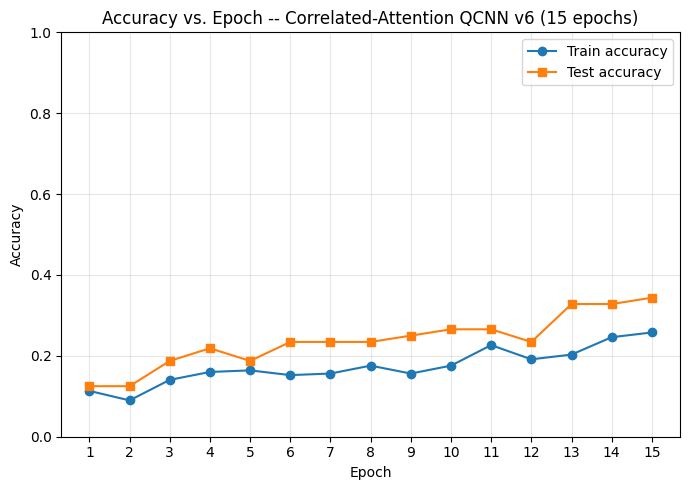

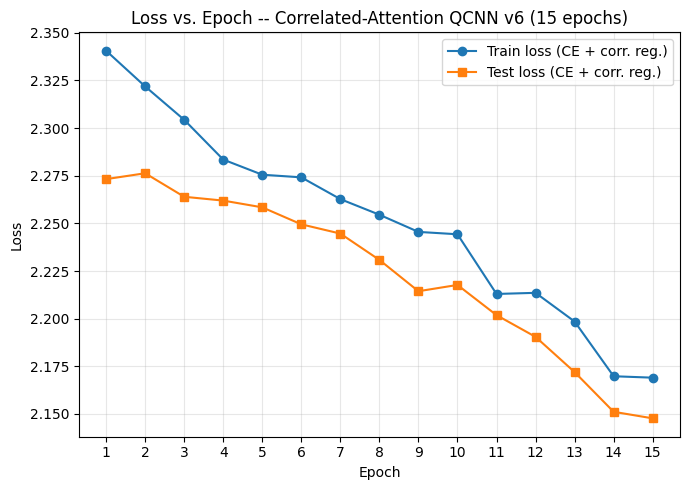

In [ ]:
import matplotlib.pyplot as plt

epochs_axis = list(range(1, N_EPOCHS + 1))

plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_accs, marker='o', label='Train accuracy')
plt.plot(epochs_axis, test_accs,  marker='s', label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs. Epoch -- Correlated-Attention QCNN v6 ({N_EPOCHS} epochs)')
plt.xticks(epochs_axis)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_vs_epoch_v6.png', dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_losses, marker='o', label='Train loss (CE + corr. reg.)')
plt.plot(epochs_axis, test_losses,  marker='s', label='Test loss (CE + corr. reg.)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Loss vs. Epoch -- Correlated-Attention QCNN v6 ({N_EPOCHS} epochs)')
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_vs_epoch_v6.png', dpi=150)
plt.show()


## 13. Loss landscape around the trained (post-15-epoch) weights

Same filter-normalized random-direction method (Li et al., 2018) as the
v5 notebook: two random directions `d1`, `d2` are rescaled per parameter
tensor to that tensor's own norm, then
`L(alpha, beta) = loss(theta* + alpha*d1 + beta*d2)` is evaluated over an
`alpha, beta` grid around the final trained weights `theta*` and plotted.
`loss` here is the full training objective (CE + correlation-regularization
term), matching what was actually optimized. The landscape is evaluated on
one fixed batch (forward pass only); weights are restored to `theta*`
afterwards.


In [ ]:
def get_flat_params(m):
    return torch.cat([p.data.view(-1) for p in m.parameters()])

def set_flat_params(m, flat):
    idx = 0
    for p in m.parameters():
        n = p.numel()
        p.data.copy_(flat[idx:idx + n].view_as(p))
        idx += n

theta_star = get_flat_params(model).clone()
params_list = list(model.parameters())

def random_direction(m):
    return [torch.randn_like(p) for p in m.parameters()]

def filter_normalize(direction, params):
    out = []
    for d, p in zip(direction, params):
        scale = p.data.norm() / (d.norm() + 1e-10)
        out.append(d * scale)
    return out

torch.manual_seed(42)
dir1 = filter_normalize(random_direction(model), params_list)
dir2 = filter_normalize(random_direction(model), params_list)
dir1_flat = torch.cat([d.view(-1) for d in dir1])
dir2_flat = torch.cat([d.view(-1) for d in dir2])

LANDSCAPE_GRID  = 11      # 11x11 = 121 model evaluations
ALPHA_RANGE     = 1.0
xb_land, yb_land = next(iter(train_loader))
xb_land, yb_land = xb_land.to(DEVICE), yb_land.to(DEVICE)

alphas = np.linspace(-ALPHA_RANGE, ALPHA_RANGE, LANDSCAPE_GRID)
betas  = np.linspace(-ALPHA_RANGE, ALPHA_RANGE, LANDSCAPE_GRID)
loss_grid = np.zeros((LANDSCAPE_GRID, LANDSCAPE_GRID))

model.eval()
t0 = time.time()
with torch.no_grad():
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            flat = theta_star + a * dir1_flat + b * dir2_flat
            set_flat_params(model, flat)
            log_probs, corr_reg, _ = model(xb_land)
            full_loss = F.nll_loss(log_probs, yb_land) + LAMBDA_CORR * corr_reg
            loss_grid[i, j] = full_loss.item()
print(f"loss landscape grid computed in {time.time()-t0:.1f}s "
      f"({LANDSCAPE_GRID**2} model evaluations, batch size {xb_land.shape[0]})")

set_flat_params(model, theta_star)
print("model weights restored to the post-training (theta*) values")


loss landscape grid computed in 80.0s (121 model evaluations, batch size 32)
model weights restored to the post-training (theta*) values


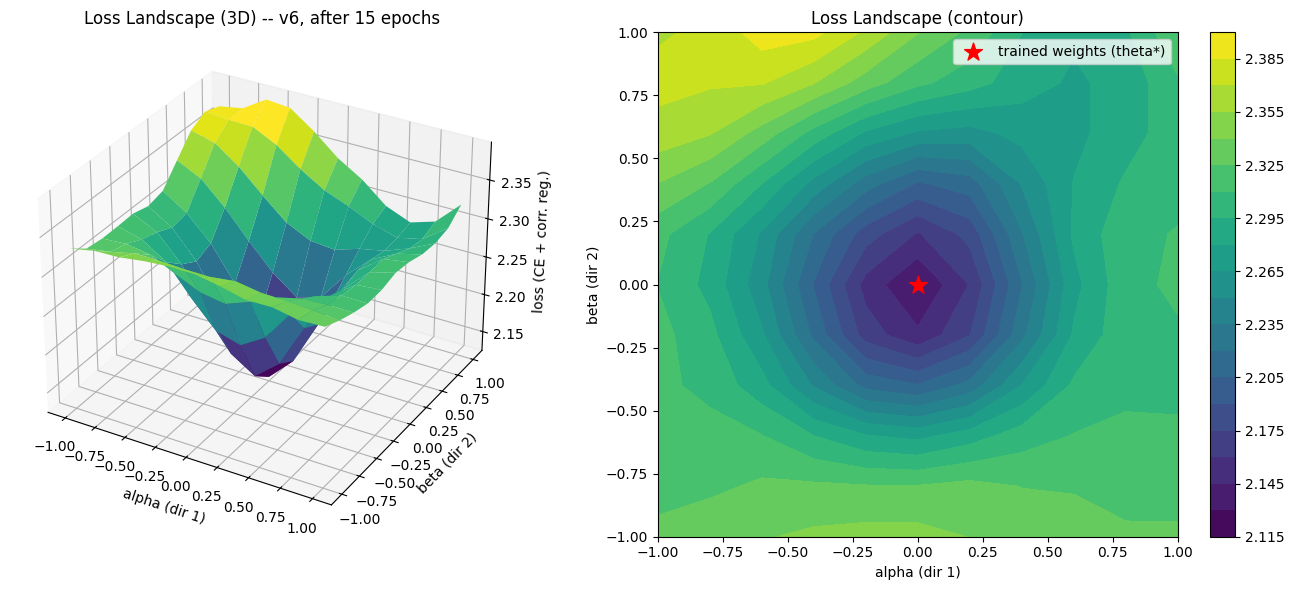

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

A, B = np.meshgrid(alphas, betas, indexing='ij')

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(A, B, loss_grid, cmap='viridis', edgecolor='none', antialiased=True)
ax1.set_xlabel('alpha (dir 1)')
ax1.set_ylabel('beta (dir 2)')
ax1.set_zlabel('loss (CE + corr. reg.)')
ax1.set_title(f'Loss Landscape (3D) -- v6, after {N_EPOCHS} epochs')

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(A, B, loss_grid, levels=25, cmap='viridis')
ax2.scatter([0], [0], color='red', marker='*', s=180, label='trained weights (theta*)', zorder=5)
ax2.set_xlabel('alpha (dir 1)')
ax2.set_ylabel('beta (dir 2)')
ax2.set_title('Loss Landscape (contour)')
ax2.legend()
fig.colorbar(cs, ax=ax2)

plt.tight_layout()
plt.savefig('loss_landscape_v6.png', dpi=150)
plt.show()


## 14. Summary of changes vs. v5

**Classical side (shrunk):**
- CNN first conv layer `3->8` &rarr; `3->4` channels: front-end params roughly
  halved (see printed counts in Sec. 6).
- Classifier head unchanged (`Linear(256, 10)`) -- this is the one classical
  block that can't shrink without changing the 64-partitions x 4-features
  output width the quantum block produces.

**Quantum side (deepened, per Senokosov et al.'s parallel-circuit idea):**
- Re-upload entangling ring applied `ENT_ROUNDS = 2` times per chunk (v5: 1).
- Main QCNN convolution depth `CONV_DEPTH = 4` (v5: 2).
- New `ATTN_DEPTH = 2` unpooled QCNN block on the 4 kept qubits, purely
  adding quantum capacity before measurement.
- Net effect: quantum trainable parameters roughly double vs. v5, while
  classical CNN parameters roughly halve -- shifting the parameter budget
  toward the quantum side as requested.

**New mechanisms (per Seong & Kim and Pandey & Mandal):**
- `feature_correlation_reg` adds a loss term pulling the CNN's per-partition
  features toward ~0.5 mean correlation before they hit the quantum circuit
  (Seong & Kim's CNN-QNN correlation-optimization idea).
- The pooling step's *dropped* qubits (still present in the simulated state,
  since pooling here is a controlled rotation, not physical qubit loss) are
  read out as a joint-parity attention logit and used to softmax-reweight
  the 64 partitions' contributions to the final feature vector -- a quantum
  attention mechanism (Pandey & Mandal's QAttn idea) added at **zero extra
  circuit evaluations**.

**Honest caveat:** none of the three cited papers' reported accuracy gains
transfer automatically to this architecture -- they were measured on
different backbones, training budgets, and (in two of the three cases)
binary rather than 10-class problems. This notebook combines their
*mechanisms*; whether the combination actually beats a classical CNN on
full CIFAR-10 by more than noise can only be established by the real
50-epoch-plus run these smoke-test cells are standing in for.
